REGION GROWING ALGORITHM,TRY TO USE BOTTOM UP APPROACH

In [1]:
!pip install scikit-image scikit-learn opencv-python rasterio matplotlib numpy

  Using cached scikit_image-0.24.0-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached scikit_learn-1.5.1-cp310-cp310-win_amd64.whl (11.0 MB)
  Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)
  Using cached rasterio-1.3.10-cp310-cp310-win_amd64.whl (24.3 MB)
  Using cached matplotlib-3.9.1-cp310-cp310-win_amd64.whl (8.0 MB)
  Using cached numpy-2.0.1-cp310-cp310-win_amd64.whl (16.6 MB)
  Using cached pillow-10.4.0-cp310-cp310-win_amd64.whl (2.6 MB)
  Using cached tifffile-2024.7.24-py3-none-any.whl (226 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
  Using cached scipy-1.14.0-cp310-cp310-win_amd64.whl (44.8 MB)
  Using cached imageio-2.34.2-py3-none-any.whl (313 kB)
  Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)
  Using cached click_plugins-1.1.1-py2.py3-none-any.whl (7.5 kB)
  Using cached affine-2.4.0-py3-none-any.whl (15 kB)
  Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
  Us

You should consider upgrading via the 'C:\Users\HARISSH\Desktop\POC\env\Scripts\python.exe -m pip install --upgrade pip' command.


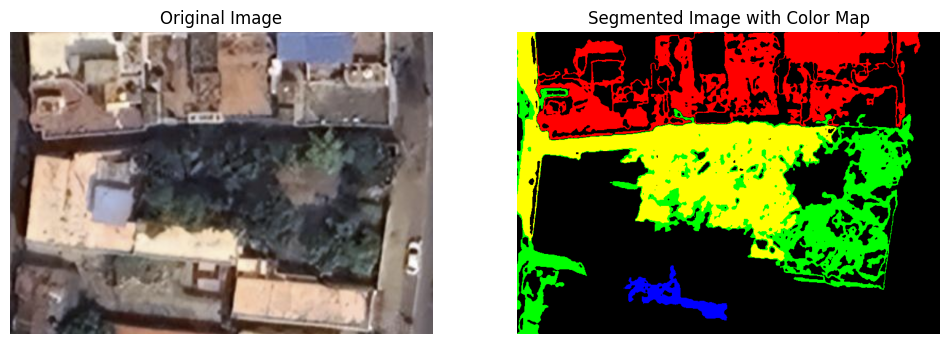

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.segmentation import flood_fill
from skimage.color import rgb2gray

def region_growing(image, seeds, threshold=0.2):
    segmented_image = np.zeros_like(image)
    for i, seed in enumerate(seeds):
        mask = flood_fill(image, seed, 1, tolerance=threshold)
        segmented_image[mask == 1] = i + 1
    return segmented_image

def multi_class_segmentation(image, seed_points, threshold=0.2):
    # Check if image has 4 channels and convert to 3 channels if necessary
    if image.shape[2] == 4:
        image = image[:, :, :3]
        
    gray_image = rgb2gray(image)
    segmented_image = region_growing(gray_image, seed_points, threshold)
    return segmented_image

def apply_color_map(segmented_image, color_map):
    height, width = segmented_image.shape
    color_image = np.zeros((height, width, 3), dtype=np.uint8)
    for label, color in color_map.items():
        color_image[segmented_image == label] = color
    return color_image

# Load sample image
image = io.imread(r'C:\Users\HARISSH\OneDrive\Pictures\Screenshots\Screenshot 2024-07-29 152322.png')

# Define seed points for each region (manually or using some heuristic)
seed_points = [(100, 100), (300, 300), (400, 200),(300,340)]

# Perform multi-class segmentation
segmented_image = multi_class_segmentation(image, seed_points, threshold=0.1)

# Define color map for each region
color_map = {
    1: [255, 0, 0],   # Red
    2: [0, 255, 0],   # Green
    3: [0, 0, 255],   # Blue
    4: [255, 255, 0], # Yellow
    5: [0, 255, 255], # Cyan
    6: [255, 0, 255]  # Magenta   
}

# Apply color map to segmented image
color_segmented_image = apply_color_map(segmented_image, color_map)

# Display results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(color_segmented_image)
ax[1].set_title('Segmented Image with Color Map')
ax[1].axis('off')

plt.show()


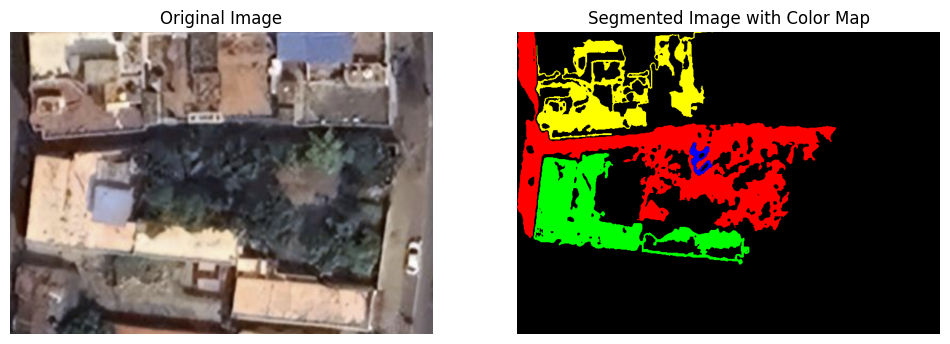

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.segmentation import flood_fill
from skimage.color import rgb2gray
from sklearn.cluster import KMeans

def region_growing(image, seeds, threshold=0.2):
    segmented_image = np.zeros_like(image)
    for i, seed in enumerate(seeds):
        mask = flood_fill(image, seed, 1, tolerance=threshold)
        segmented_image[mask == 1] = i + 1
    return segmented_image

def multi_class_segmentation(image, seed_points, threshold=0.2):
    # Check if image has 4 channels and convert to 3 channels if necessary
    if image.shape[2] == 4:
        image = image[:, :, :3]
        
    gray_image = rgb2gray(image)
    segmented_image = region_growing(gray_image, seed_points, threshold)
    return segmented_image

def apply_color_map(segmented_image, color_map):
    height, width = segmented_image.shape
    color_image = np.zeros((height, width, 3), dtype=np.uint8)
    for label, color in color_map.items():
        color_image[segmented_image == label] = color
    return color_image

def find_seed_points(image, n_clusters=3):
    gray_image = rgb2gray(image).reshape(-1, 1)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(gray_image)
    labels = kmeans.labels_.reshape(image.shape[:2])
    cluster_centers = kmeans.cluster_centers_
    
    seed_points = []
    for cluster_value in range(n_clusters):
        y, x = np.where(labels == cluster_value)
        seed_points.append((y[len(y) // 2], x[len(x) // 2]))
    return seed_points

# Load sample image
image = io.imread(r'C:\Users\HARISSH\OneDrive\Pictures\Screenshots\Screenshot 2024-07-29 152322.png')

if image.shape[2] == 4:
    image = image[:, :, :3]


# Automatically find seed points using K-means clustering
seed_points = find_seed_points(image, n_clusters=4)

# Perform multi-class segmentation
segmented_image = multi_class_segmentation(image, seed_points, threshold=0.1)

# Define color map for each region
color_map = {
    1: [255, 0, 0],   # Red
    2: [0, 255, 0],   # Green
    3: [0, 0, 255],   # Blue
    4: [255, 255, 0], # Yellow
    5: [0, 255, 255], # Cyan
    6: [255, 0, 255]  # Magenta   
}

# Apply color map to segmented image
color_segmented_image = apply_color_map(segmented_image, color_map)

# Display results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(color_segmented_image)
ax[1].set_title('Segmented Image with Color Map')
ax[1].axis('off')

plt.show()
